## <b> Appendix 1: Python Code and Output
<br>

**Management/Research Question**: What impacts house prices in Ames, Iowa, the most, and which model will allow us to predict these prices most accurately?
<br><br>
Our hypothesis is that house prices are linearly influenced by inherent features like overall construction quality, the age of the house, living area, and outdoor space. We will test this hypothesis by exploring the distribution of the target variable, `SalePrice`, and the linear relationships exhibited by the other features to the target. Then, we will build regression models using the training set and evaluate polynomial and other engineered features. Through this analysis, we aim to derive valuable insights from the Ames housing market so as to support better decision-making.

The conclusions of this analysis will support buyers in understanding whether a house is overpriced, sellers in understanding if the house is underpriced, and the government on what the appropriate valuation should be for taxation assessment.

<b> Methodological Assumptions and Limitations of the training dataset </b>

**Assumptions:**
- Linear relationships exist between predictors and the sale price
- Missing data is missing due to randomness for the variables dropped
- Outliers represent a legitimate market segment rather than unrelated data points or data errors

**Limitations:**
- The dataset considers a time when the United States was facing a housing crisis (2006-2010), which might impact utility of the analysis
- The analysis does not consider home proximity to good schools, places of interest, and other indicators. 

### 1. IMPORTS AND DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 2. EXPLORATORY DATA ANALYSIS (EDA)

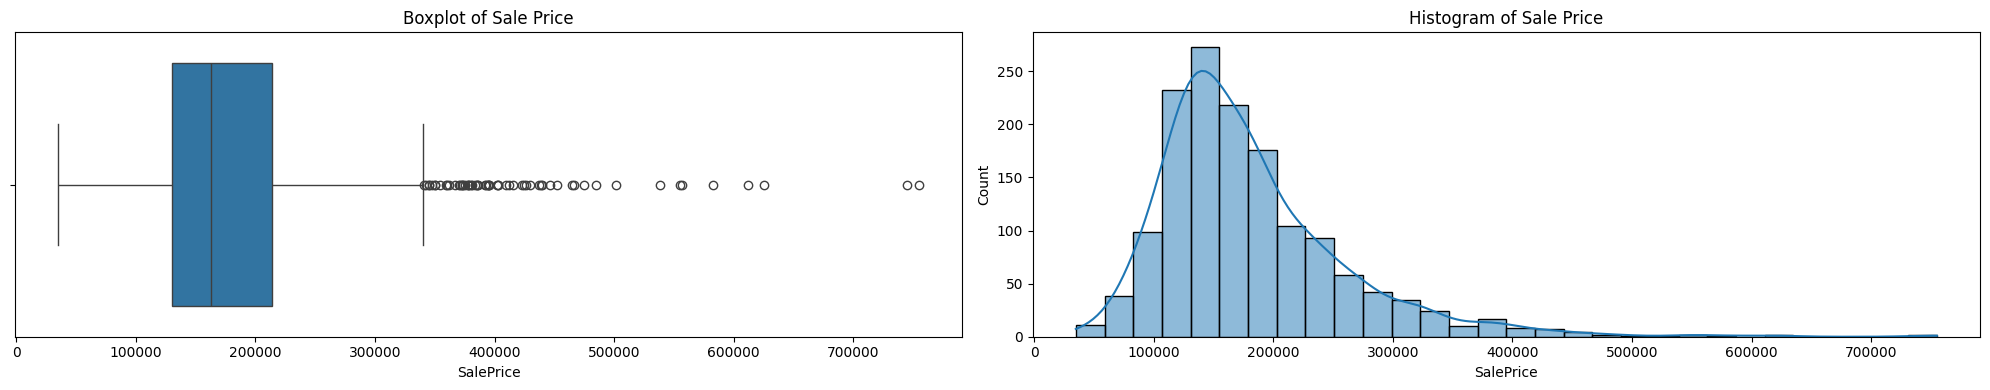

Skewness and Kurtosis of SalePrice:
Skewness: 1.8829
Kurtosis: 6.5363


In [3]:
# Boxplot of SalePrice
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=train['SalePrice'])
plt.title('Boxplot of Sale Price')

# Histogram of SalePrice
plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice'], bins=30, kde=True)
plt.title('Histogram of Sale Price')
plt.tight_layout()
plt.show()

# Evaluating Skewness and Kurtosis of SalePrice
print("Skewness and Kurtosis of SalePrice:")
print("Skewness:", round(train['SalePrice'].skew(), 4))
print("Kurtosis:", round(train['SalePrice'].kurt(), 4))

Observing the boxplot, we note that `SalePrice` has several outliers (i.e., home prices over $500K). Though low in number, these outliers can inadvertently throw off any linear relationships we may explore.

The histogram and the skewness/kurtosis measures confirm that `SalePrice` is strongly skewed to the right, i.e., most house prices are clustered at the lower end, with a long tail of higher prices. Additionally, the kurtosis of 6.5363 suggests that house prices  distribution has heavier tails and a sharper peak than a normal distribution, which means that we should expect more frequent and more extreme outliers. Considering the abnormal shape, we will normalize the distribution and explore its relationship to the other features.

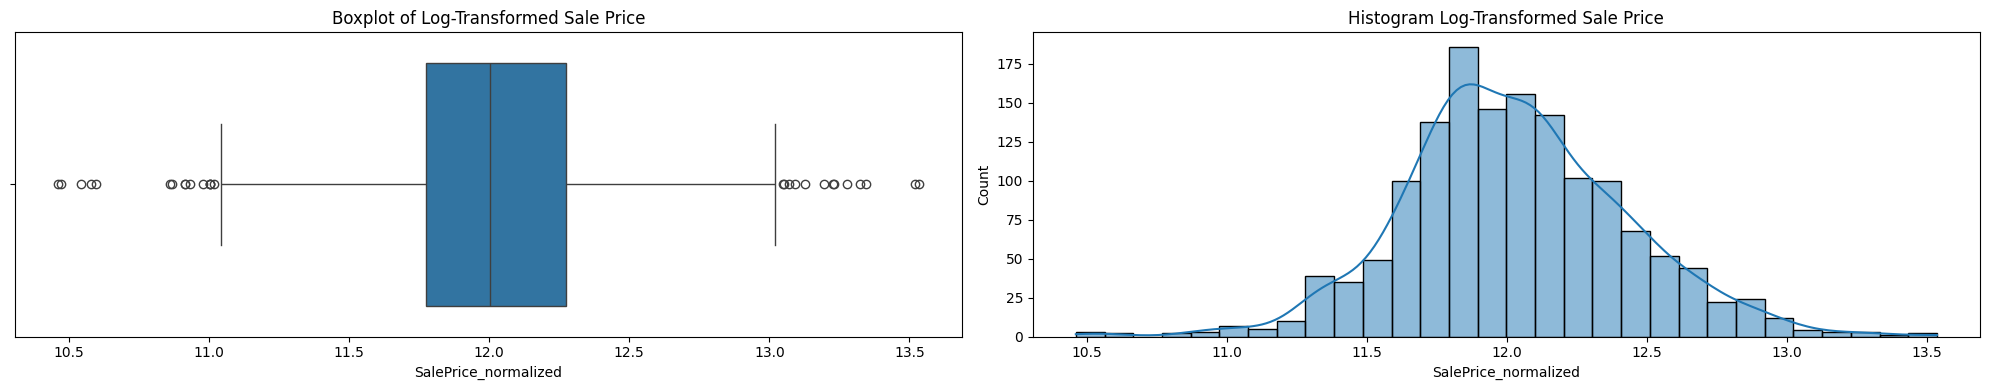

Skewness and Kurtosis of normalized SalePrice:
Skewness: 0.1213
Kurtosis: 0.8095


In [4]:
# Log-transform the target for normality
train['SalePrice_normalized'] = np.log1p(train['SalePrice'])

# Boxplot of Normalized SalePrice
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=train['SalePrice_normalized'])
plt.title('Boxplot of Log-Transformed Sale Price')

# Histogram of Normalized SalePrice
plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice_normalized'], bins=30, kde=True)
plt.title('Histogram Log-Transformed Sale Price')
plt.tight_layout()
plt.show()

# Evaluating Skewness and Kurtosis of SalePrice_normalized
print("Skewness and Kurtosis of normalized SalePrice:")
print("Skewness:", round(train['SalePrice_normalized'].skew(), 4))
print("Kurtosis:", round(train['SalePrice_normalized'].kurt(), 4))

The normalized SalePrice distribution is nearly symmetric, with a skew close to zero, and the outliers are evenly distributed now. The distribution has an excess kurtosis less than three, indicating only a mild presence of outliers/heavier tails. Overall, the distribution is close to normal.

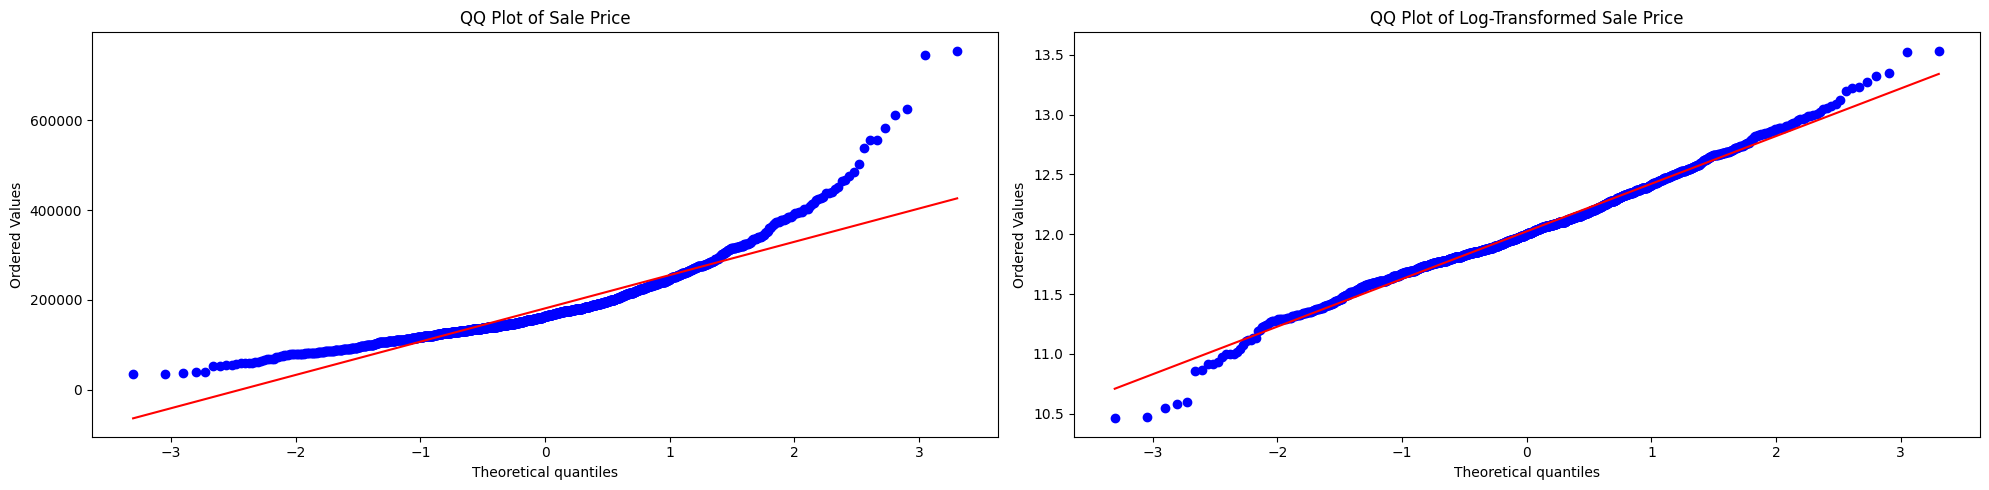

In [5]:
# QQ plot for SalePrice
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
stats.probplot(train['SalePrice'], dist="norm", plot=plt)
plt.title('QQ Plot of Sale Price')

# QQ plot for SalePrice_normalized
plt.subplot(1, 2, 2)
stats.probplot(train['SalePrice_normalized'], dist="norm", plot=plt)
plt.title('QQ Plot of Log-Transformed Sale Price')
plt.tight_layout()
plt.show()

QQ plots compare a given distribution to a theoretical normal distribution. Here, we see that `SalePrice` has heavy-tails and several outliers as confirmed by histogram and boxplots. The points deviate significantly from the red line, especially at the ends (tails). On the right, we note that the log-transformed `SalePrice_normalized` is much more tightly bound around the red-line (i.e. normal distribution). 

To conclude, log-transforming the target variable helps us analyze and model it better as most regression models require/assume normality.

#### 2.1 EVALUATING THE OTHER FEATURES IN THE TRAINING DATASET

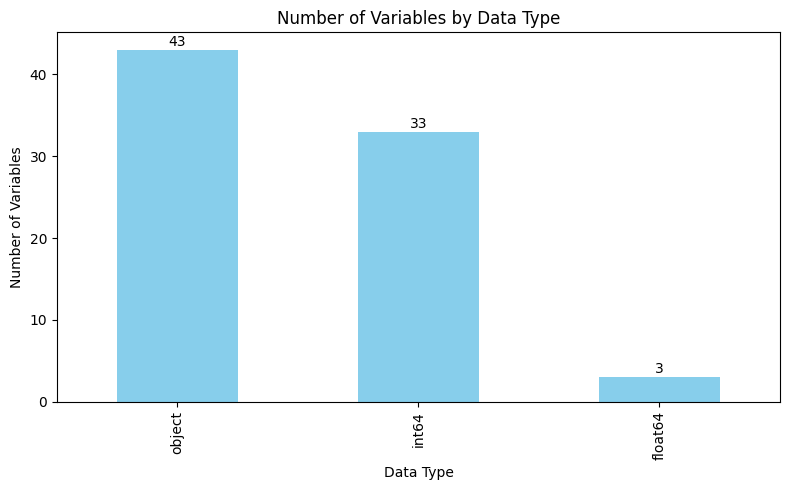

In [6]:
other_features = train.drop(columns=['SalePrice', 'SalePrice_normalized', 'Id'])
data_types = other_features.dtypes.value_counts()

# Plotting the data types of the variables
plt.figure(figsize=(8, 5))
ax = data_types.plot(kind='bar', color='skyblue')

# Adding data labels for clarity
for i, v in enumerate(data_types.values):
    ax.text(i, v + 0.5, str(v), color='black', ha='center')

plt.ylabel('Number of Variables')
plt.xlabel('Data Type')
plt.title('Number of Variables by Data Type')
plt.tight_layout()
plt.show()

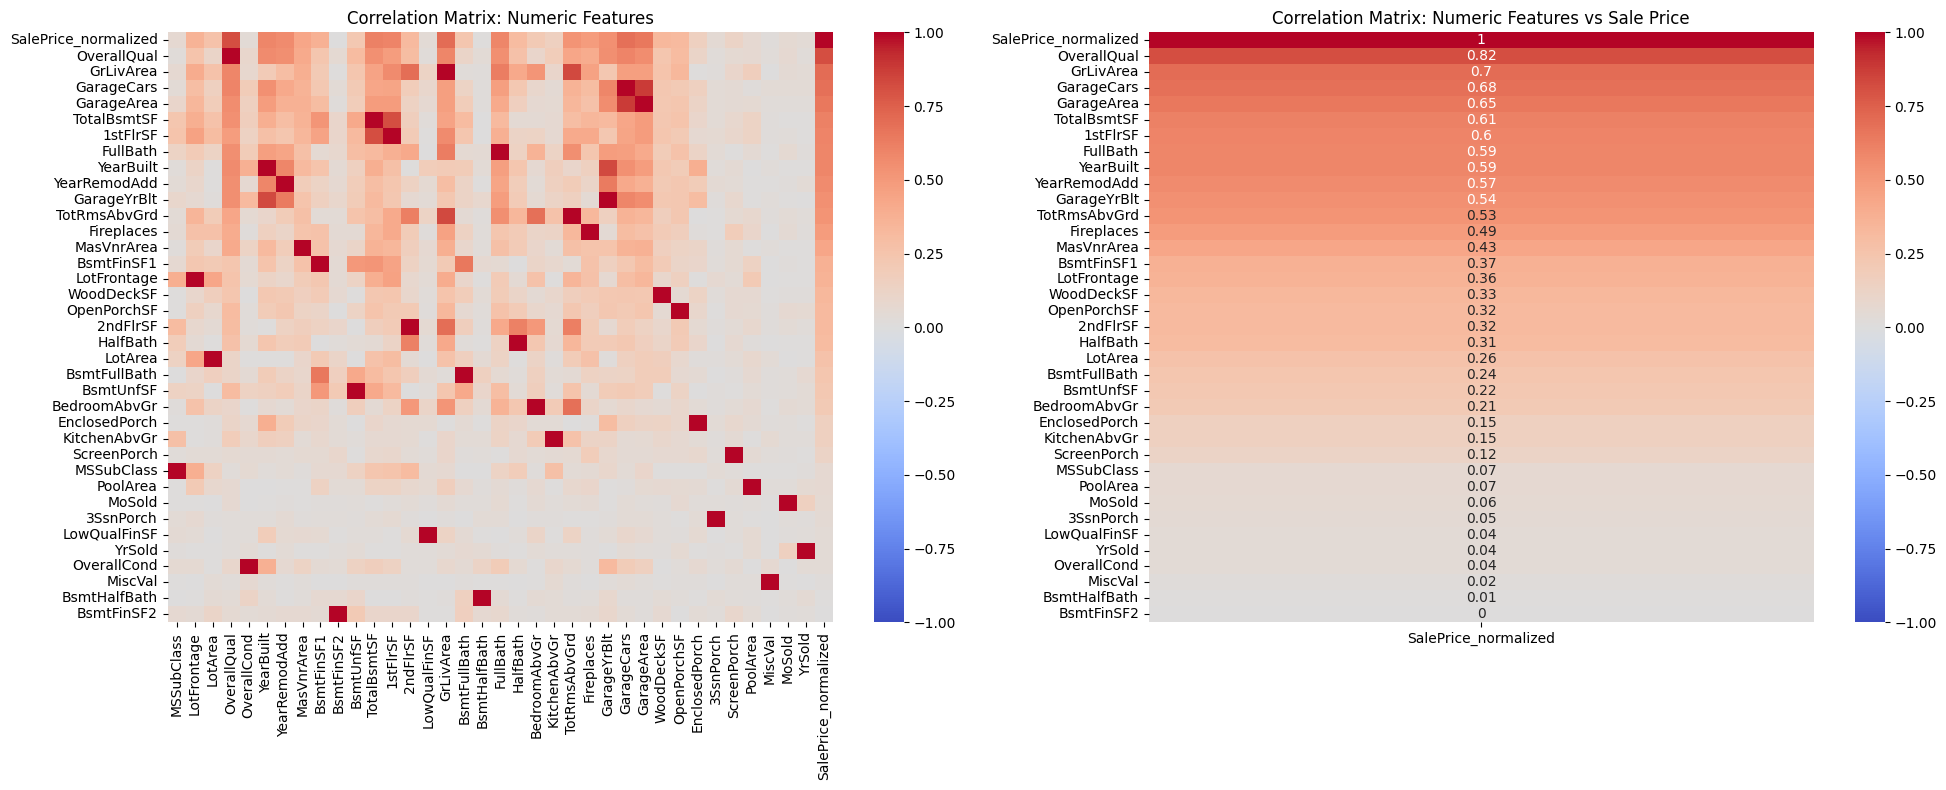

In [7]:
# Correlation matrix for numeric variables vs train['SalePrice_normalized']
numeric_cols = train.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop(['Id', 'SalePrice'])

# Add SalePrice_normalized to the numeric columns for correlation calculation
correlations = round(train[numeric_cols].corr().abs().sort_values(by='SalePrice_normalized', ascending=False), 2)

# Create figure and plot correlation matrix
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.heatmap(correlations, 
            vmin=-1, vmax=1, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix: Numeric Features')

plt.subplot(1, 2, 2)
# Create a single column heatmap for correlations with SalePrice_normalized
corr_target = correlations['SalePrice_normalized'].to_frame()
sns.heatmap(corr_target, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Numeric Features vs Sale Price')

plt.tight_layout()
plt.show()

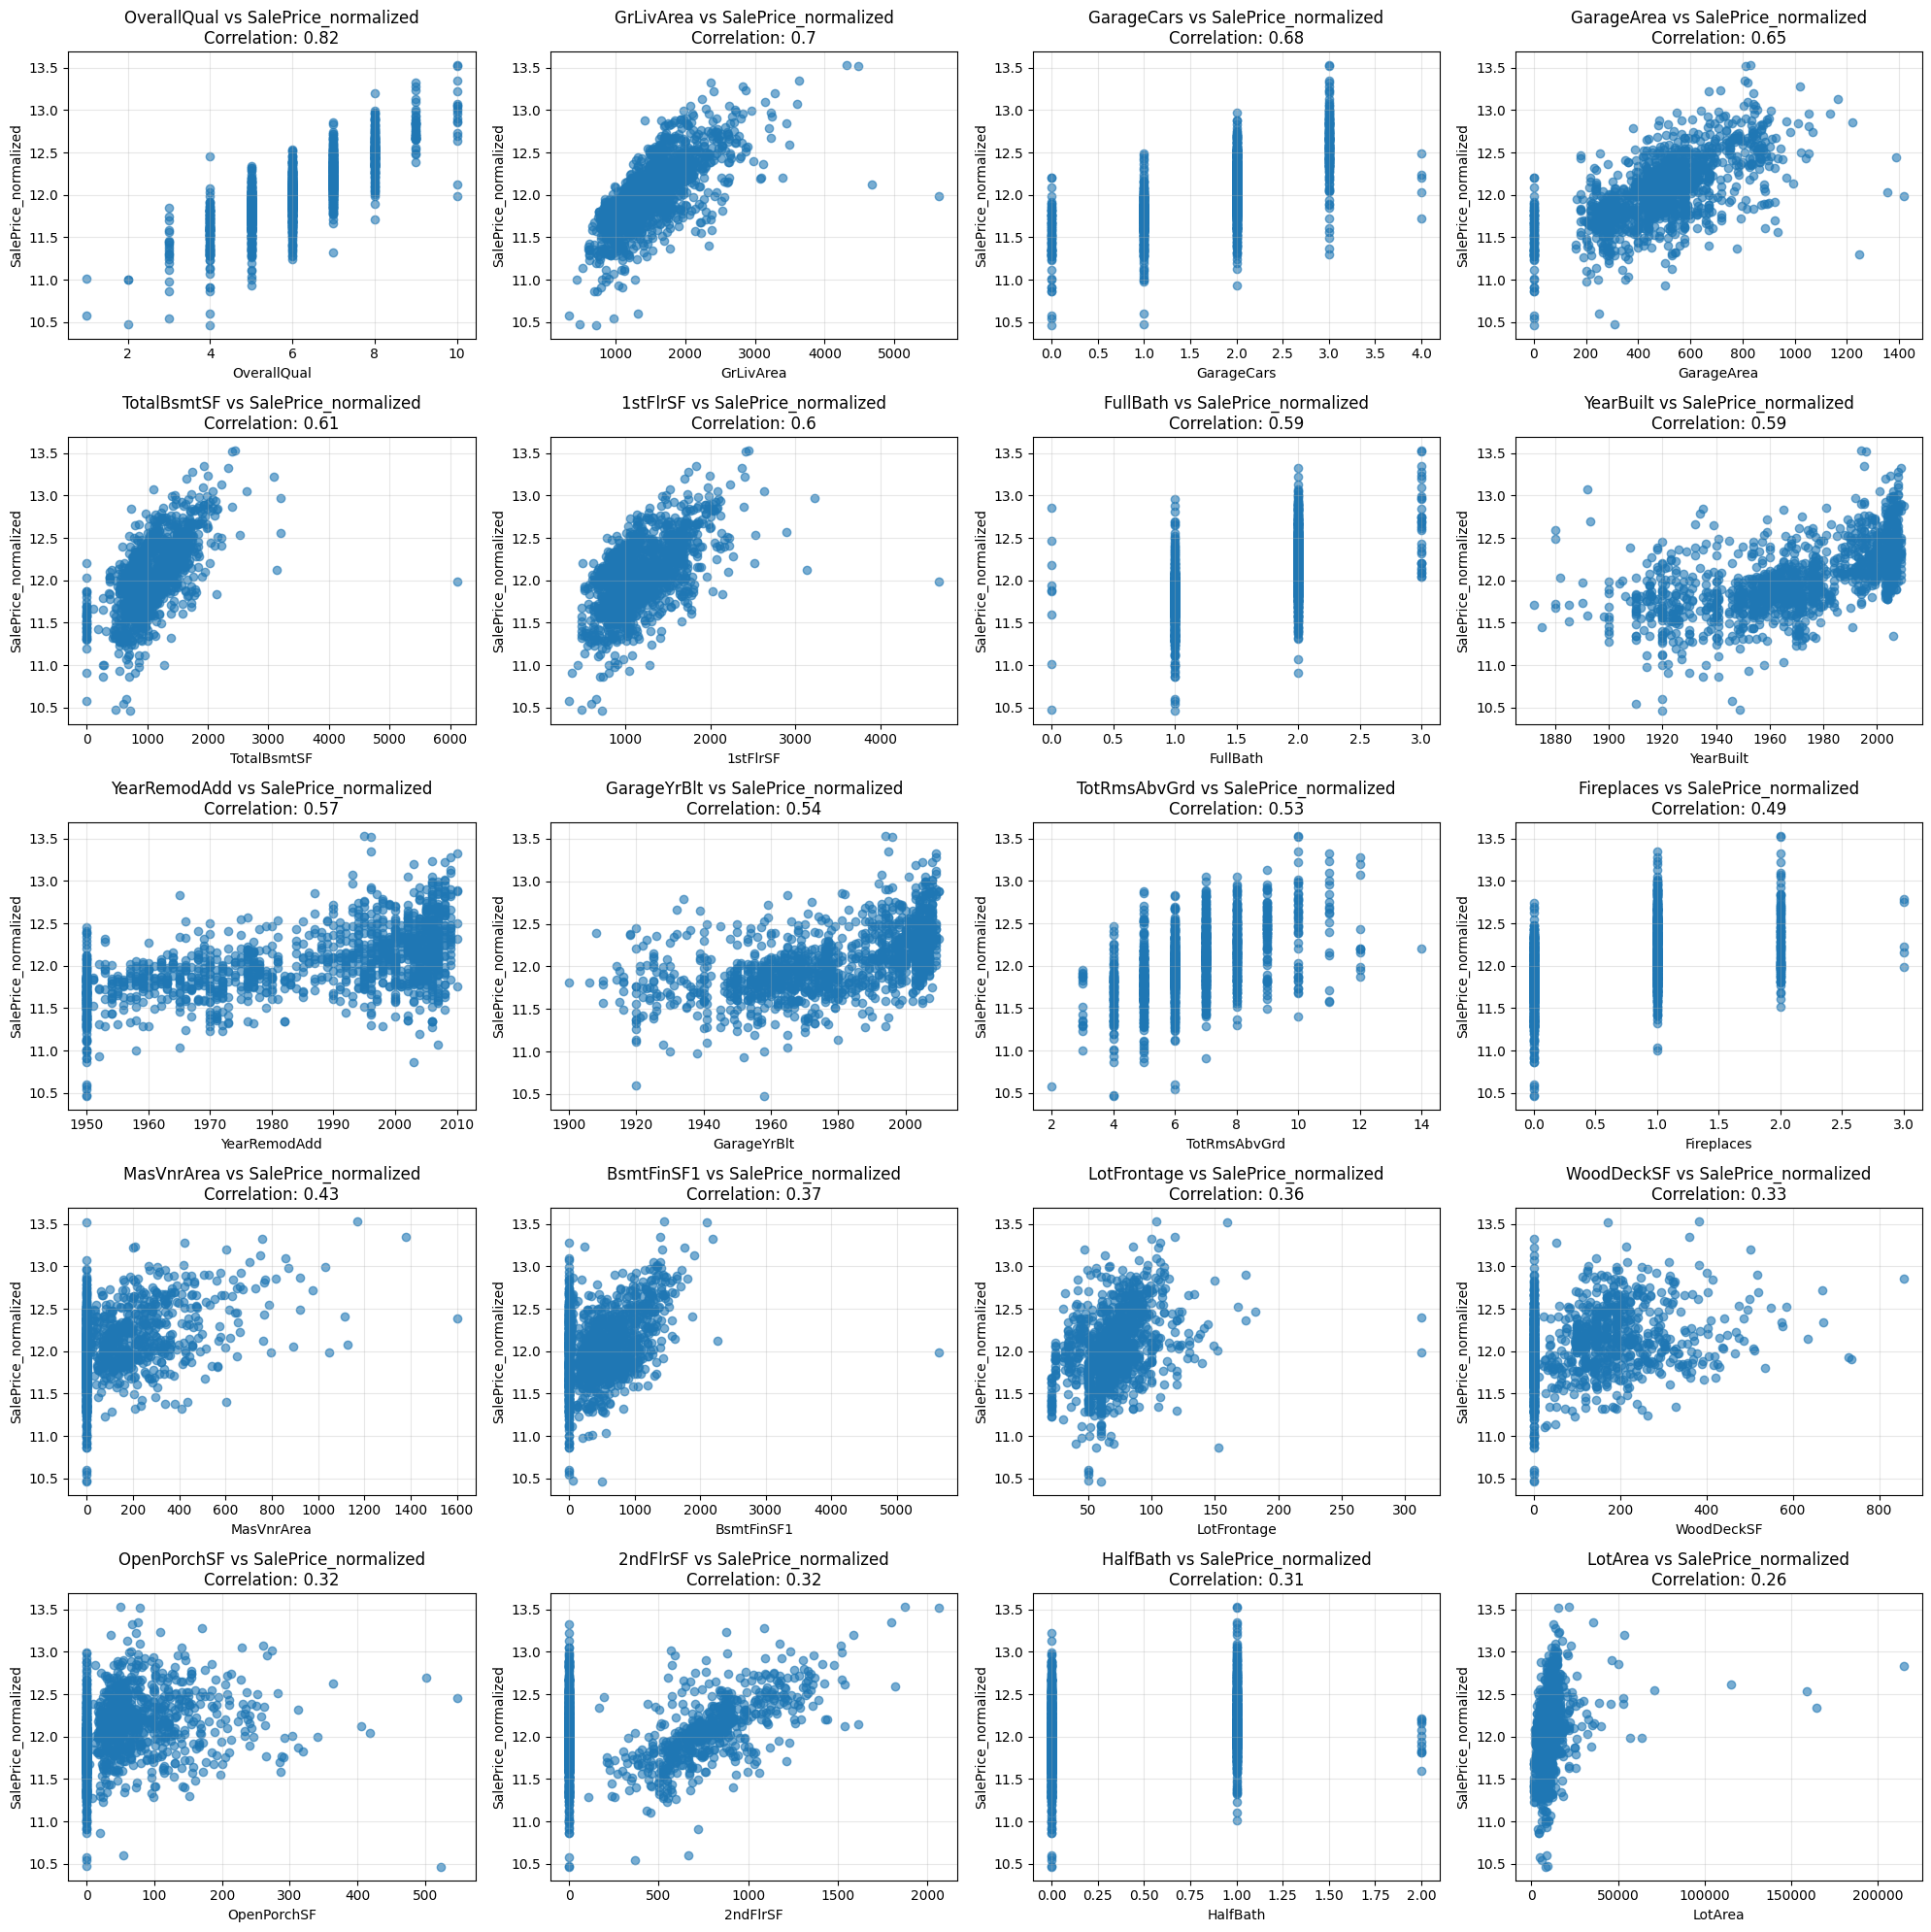

In [8]:
# Filter features with more than 25% correlation with SalePrice_normalized
high_corr_features = correlations['SalePrice_normalized'].head(21)

# Remove SalePrice_normalized itself from the list
high_corr_features = high_corr_features.drop('SalePrice_normalized')

# Create scatterplots for each high correlation feature
n_features = len(high_corr_features)

# Calculate subplot dimensions
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(20, 20))
    
for i, feature in enumerate(high_corr_features.index):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(train[feature], train['SalePrice_normalized'], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel('SalePrice_normalized')
    plt.title(f'{feature} vs SalePrice_normalized\nCorrelation: {high_corr_features[feature]}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We generated and evaluated these scatterplots to give readers an understanding of the numeric features' relationships with the target. Additionally:

1. *Interpretability*: We can interpret the impact of features, like square footage and lot area, on the model when they are untransformed.

2. *Model flexibility*: To handle non-linear effects, we will transform the features using polynomial and interaction terms.

3. *Outlier validity*: We believe that outliers (e.g., lots over 200k sqft) represent valid market segments and their retention will better inform stakeholders. 

4. *Target transformation*: We transformed `SalePrice` to stabilized its relationship with other features and further transformation might be redundant.

### 3. FEATURE ENGINEERING


Since we have certain variables that seem related to each other, we will create new features by combining them. 

1. First, we will create `TotalSF` by adding `TotalBsmtSF` & `GrLivArea` to represent total living space of a house.
2. Second, we will create `TotalBathrooms` by combining all full and half bathrooms (with half baths weighted as 0.5), to represent the total number of bathrooms in a house.

In [9]:
# Create new variables to represent TotalBathrooms and TotalSF house has a fireplace
train['TotalBathrooms'] = (
        train['FullBath'] + (0.5 * train['HalfBath']) +
        train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath'])
    )

test['TotalBathrooms'] = (
        test['FullBath'] + (0.5 * test['HalfBath']) +
        test['BsmtFullBath'] + (0.5 * test['BsmtHalfBath'])
    )

train['TotalSF'] = train['TotalBsmtSF'] + train['GrLivArea']
test['TotalSF'] = test['TotalBsmtSF'] + test['GrLivArea']

# Removing component columns
train = train.drop(['TotalBsmtSF', 'GrLivArea', 'FullBath',  'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], axis = 1)
test = test.drop(['TotalBsmtSF', 'GrLivArea', 'FullBath',  'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], axis = 1)

#### 3.1 INDICATOR, DICHOTOMOUS, AND PIECEWISE VARIABLES

Since Ames, Iowa, experiences heavy snowfall, we assume that fireplaces offer some, if not substantial, value. We will create an indicator variable, `HasFireplace`, to evaluate this.

In [10]:
# Add indicator (dummy) variable for whether house has a fireplace
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)

Based on our general understanding, modern homes are valued higher than older ones. We will create a feature, `IsModernHome`, to evaluate the house's modernness.

In [11]:
# Variable to identify if house was built after 1980
train['IsModernHome'] = (train['YearBuilt'] >= 1980).astype(int)
test['IsModernHome'] = (test['YearBuilt'] >= 1980).astype(int)

Based on our general understanding, homes under 2,000 sqft gain value with each added square foot, but after 2,000, the gain may flatten out. We will create a piece-wise feature, `TotalSF_2000`, to evaluate the house's modernness.

In [12]:
# Variable to identify if total square footage is over 2,000 sqft
train['TotalSF_over_2000'] = np.maximum(train['TotalSF'] - 2000, 0)
test['TotalSF_over_2000'] = np.maximum(test['TotalSF'] - 2000, 0)

### 4. DATA PREPROCESSING AND FEATURE SELECTION

In [13]:
# Checking for null values in the variables against their data types
nulls_and_types = train.isnull().sum().to_frame('num_nulls')
nulls_and_types['dtype'] = train.dtypes
print(nulls_and_types.sort_values(by = 'num_nulls', ascending=False).head(20))

              num_nulls    dtype
PoolQC             1453   object
MiscFeature        1406   object
Alley              1369   object
Fence              1179   object
MasVnrType          872   object
FireplaceQu         690   object
LotFrontage         259  float64
GarageFinish         81   object
GarageType           81   object
GarageCond           81   object
GarageYrBlt          81  float64
GarageQual           81   object
BsmtFinType2         38   object
BsmtExposure         38   object
BsmtCond             37   object
BsmtQual             37   object
BsmtFinType1         37   object
MasVnrArea            8  float64
Electrical            1   object
Condition2            0   object


The median is used to fill missing values for features like MasVnrArea, LotFrontage, and GarageYrBlt because it is robust to outliers. Additionally, we believe the median is an appropriate measure to fill the missing values for numeric features as houses will generally be similar to other houses within the city. We will impute the missing variables and prepare the data for further modelling.

In [14]:
# 1. Impute missing numeric values
train = train.fillna(train.median(numeric_only=True))
test = test.fillna(test.median(numeric_only=True))

# 2. Train-Test Split
train_set, val_set = train_test_split(train, test_size=0.2, random_state=42)

# 3. Prepare training features and target
X_train_fs = train_set.drop(columns=['Id', 'SalePrice', 'SalePrice_normalized'])
y_train_fs = train_set['SalePrice_normalized']

# One-hot encode categorical variables and convert bools to int
X_train_fs = pd.get_dummies(X_train_fs, drop_first=True)
bool_cols = X_train_fs.select_dtypes(include='bool').columns
X_train_fs[bool_cols] = X_train_fs[bool_cols].astype(int)

# 4. Standardize features before feature selection
scaler_fs = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_fs)

# 5. Feature Selection with SelectKBest (f_regression)
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(X_train_scaled_fs, y_train_fs)

# Get mask of selected features and corresponding feature names
selected_mask = selector.get_support()
selected_features = X_train_fs.columns[selected_mask]
print(f"Selected {len(selected_features)} features using SelectKBest.")

# 6. Prepare final train and validation feature sets
# One-hot encode train and validation sets
X_train_all = pd.get_dummies(train_set.drop(columns=['SalePrice', 'SalePrice_normalized']), drop_first=True)
X_val_all = pd.get_dummies(val_set.drop(columns=['SalePrice', 'SalePrice_normalized']), drop_first=True)

# Align columns in train and validation sets
X_train_all, X_val_all = X_train_all.align(X_val_all, join='left', axis=1, fill_value=0)

# Select only the features chosen by SelectKBest
X_train = X_train_all[selected_features]
X_val = X_val_all[selected_features]

y_train = train_set['SalePrice_normalized']
y_val = val_set['SalePrice_normalized']

# 7. Polynomial feature expansion
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

# 8. Scale polynomial features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

Selected 20 features using SelectKBest.


*Polynomial Features*
We created a set of polynomial features to allow the regression model to capture non-linear relationships between the predictors and the target variable. Instead of using only the original features, we expand the feature set to include not just each feature itself, but also its squared value and all possible pairwise products (interactions) between features. For example, if the original features are `A` and `B`, the polynomial expansion will include `A`, `B`, `A^2`, `B^2`, and `A*B`. This is accomplished using `PolynomialFeatures(degree=2, include_bias=False)` from scikit-learn, which systematically generates all such terms up to the specified degree (here, degree 2).

*Feature Scaling:*
After polynomial expansion, the resulting feature set can have a wide range of values and scales, especially since squared and interaction terms can be much larger than the original features. Many regression algorithms (including Ridge and Linear Regression) perform better when all features are on a similar scale. To address this, we use `StandardScaler` to standardize each feature so that it has a mean of zero and a standard deviation of one. This ensures that no single feature dominates the model due to its scale, and it helps the optimization process converge more efficiently.

### 5. MODELING

In [15]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

In [16]:
# Ridge Regression
ridge = Ridge(max_iter=1000)
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

print("Best alpha for Ridge:", grid_search.best_params_['alpha'])

# Predict on validation set
ridge = Ridge(alpha=grid_search.best_params_['alpha'])
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_val_scaled)

Best alpha for Ridge: 100


In [17]:
# Lasso Regression
lasso = Lasso(max_iter=1000)
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

print("Best alpha for Lasso:", grid_search.best_params_['alpha'])

lasso.fit(X_train_scaled, y_train)

# Predict on validation set
lasso = Lasso(alpha=grid_search.best_params_['alpha'])
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_val_scaled)

Best alpha for Lasso: 0.001


In [18]:
# Elastic Regression
elastic_net = ElasticNet(max_iter=1000)

# Define the parameter grid
param_grid_elastic = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Perform grid search with cross-validation
grid_search_elastic = GridSearchCV(elastic_net, param_grid_elastic, cv=5, scoring='r2')
grid_search_elastic.fit(X_train_scaled, y_train)

# Output best parameters
print("Best alpha for ElasticNet:", grid_search_elastic.best_params_['alpha'])
print("Best l1_ratio for ElasticNet:", grid_search_elastic.best_params_['l1_ratio'])

# Fit model with best parameters
best_elastic = ElasticNet(
    alpha=grid_search_elastic.best_params_['alpha'],
    l1_ratio=grid_search_elastic.best_params_['l1_ratio'],
    max_iter=1000
)
best_elastic.fit(X_train_scaled, y_train)

# Predict on validation set
y_pred_elastic = best_elastic.predict(X_val_scaled)

Best alpha for ElasticNet: 0.01
Best l1_ratio for ElasticNet: 0.1


**Model Criteria in Simple Terms**

1. *Linear Regression*: This model makes predictions by modeling the linear relationships between the target and the features and aims to minimize the difference between actual and predicted values. 

2. *Ridge Regression*: This model makes predictions in the same fashion but penalizes overly high feature coefficients, which prevents the model from overfitting to the features. We control this using a parameter called alpha (here, set to 100). 

3. *Lasso regression*: This model is similar to Ridge but can even nullify these coefficients, effectively removing less important features from the model entirely and is controlled by a similar alpha parameter (here, set to 0.001).

4. *Elastic Net Regression*: This model combines the Ridge and Lasso models' penalty rules and allows us to reduce the risk of overfitting and select features more effectively. We control this using two parameters called alpha (overall penalty strength) and l1_ratio (how much to balance between Ridge-like and Lasso-like penalties) (here, set to 0.01 and 0.1, respectively).

### 6. MODEL DIAGNOSTICS

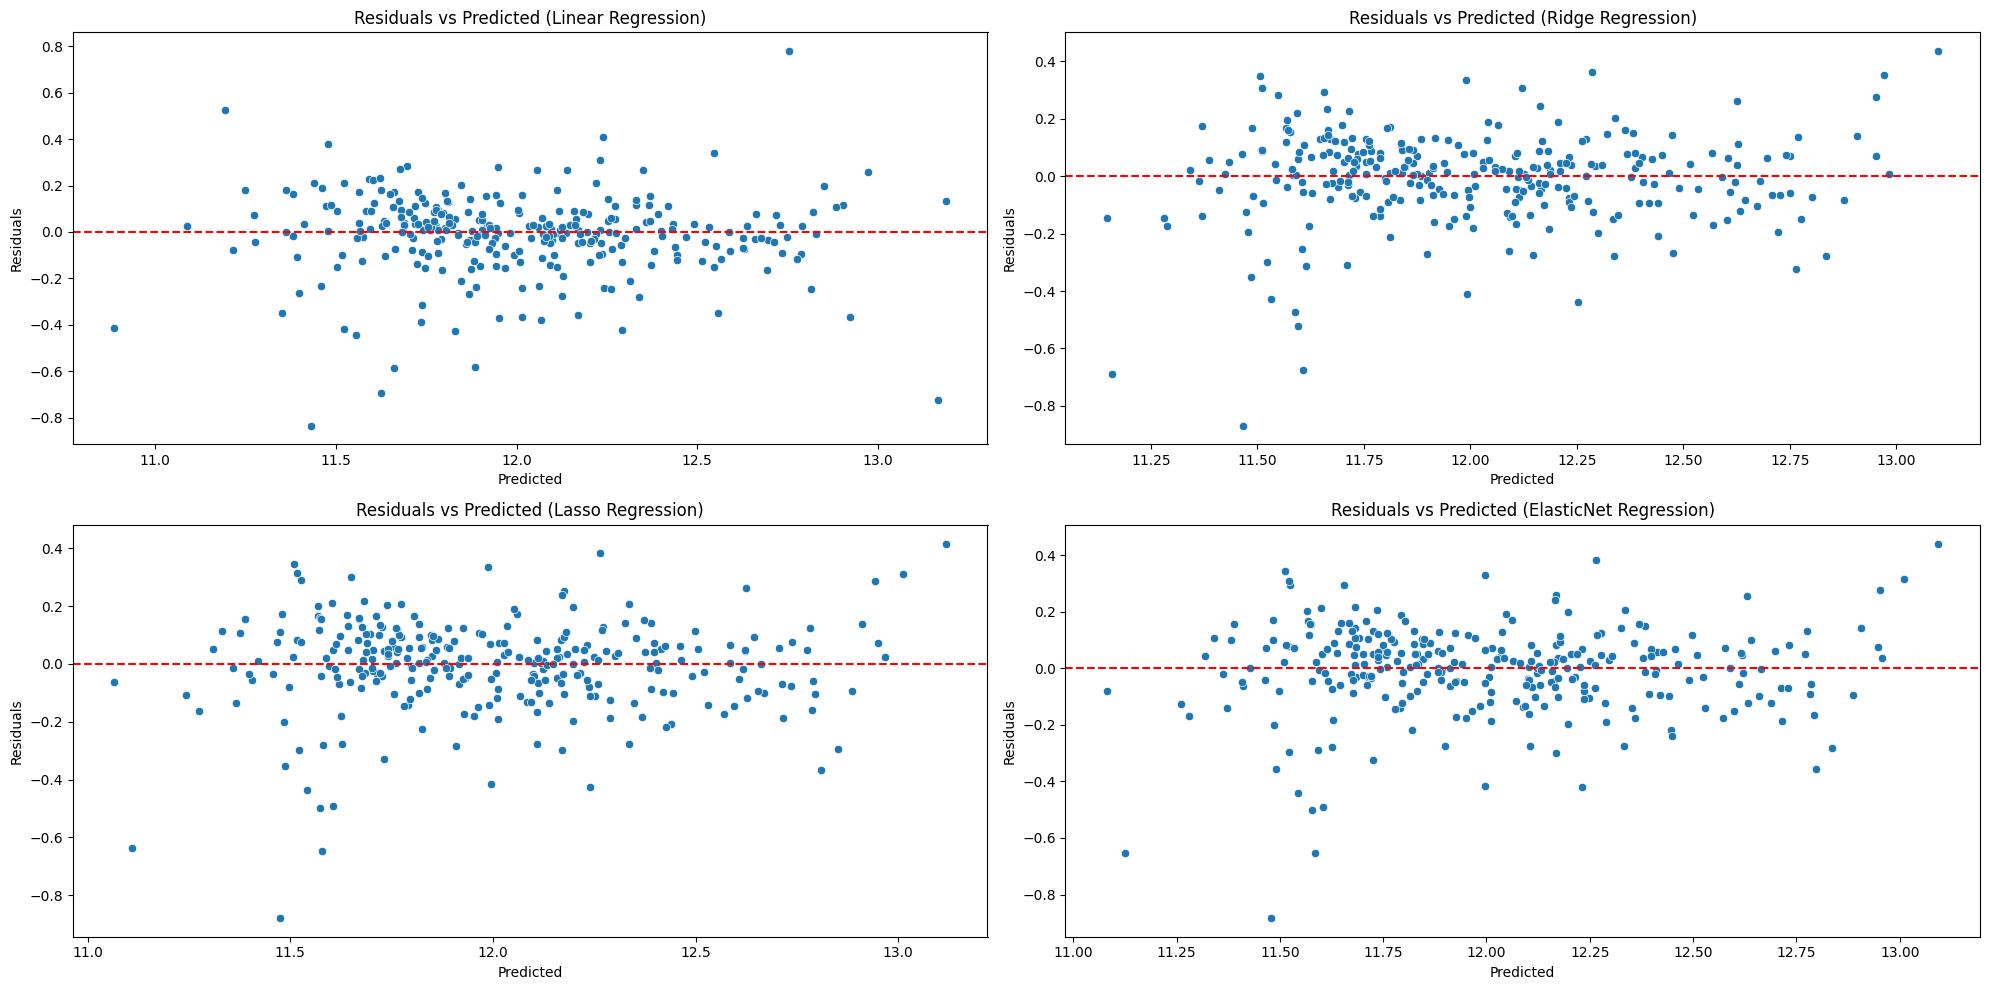

In [19]:
# Define models and their predictions
predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'ElasticNet Regression': y_pred_elastic
}

plt.figure(figsize=(20, 10))

# Scatterplot of residuals
for i, (model_name, y_pred) in enumerate(predictions.items(), 1):
    residuals = y_val - y_pred
    
    plt.subplot(2, 2, i)
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='r', linestyle='--')
    plt.title(f'Residuals vs Predicted ({model_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

The scatterplot of residuals versus predicted values can help us diagnose the performance and assumptions of a regression model. Both models' residuals are randomly scattered around zero suggest that the models errors are linear and vary constantly. The lack of a distinct pattern also suggests that there are no unaccounted variables. 

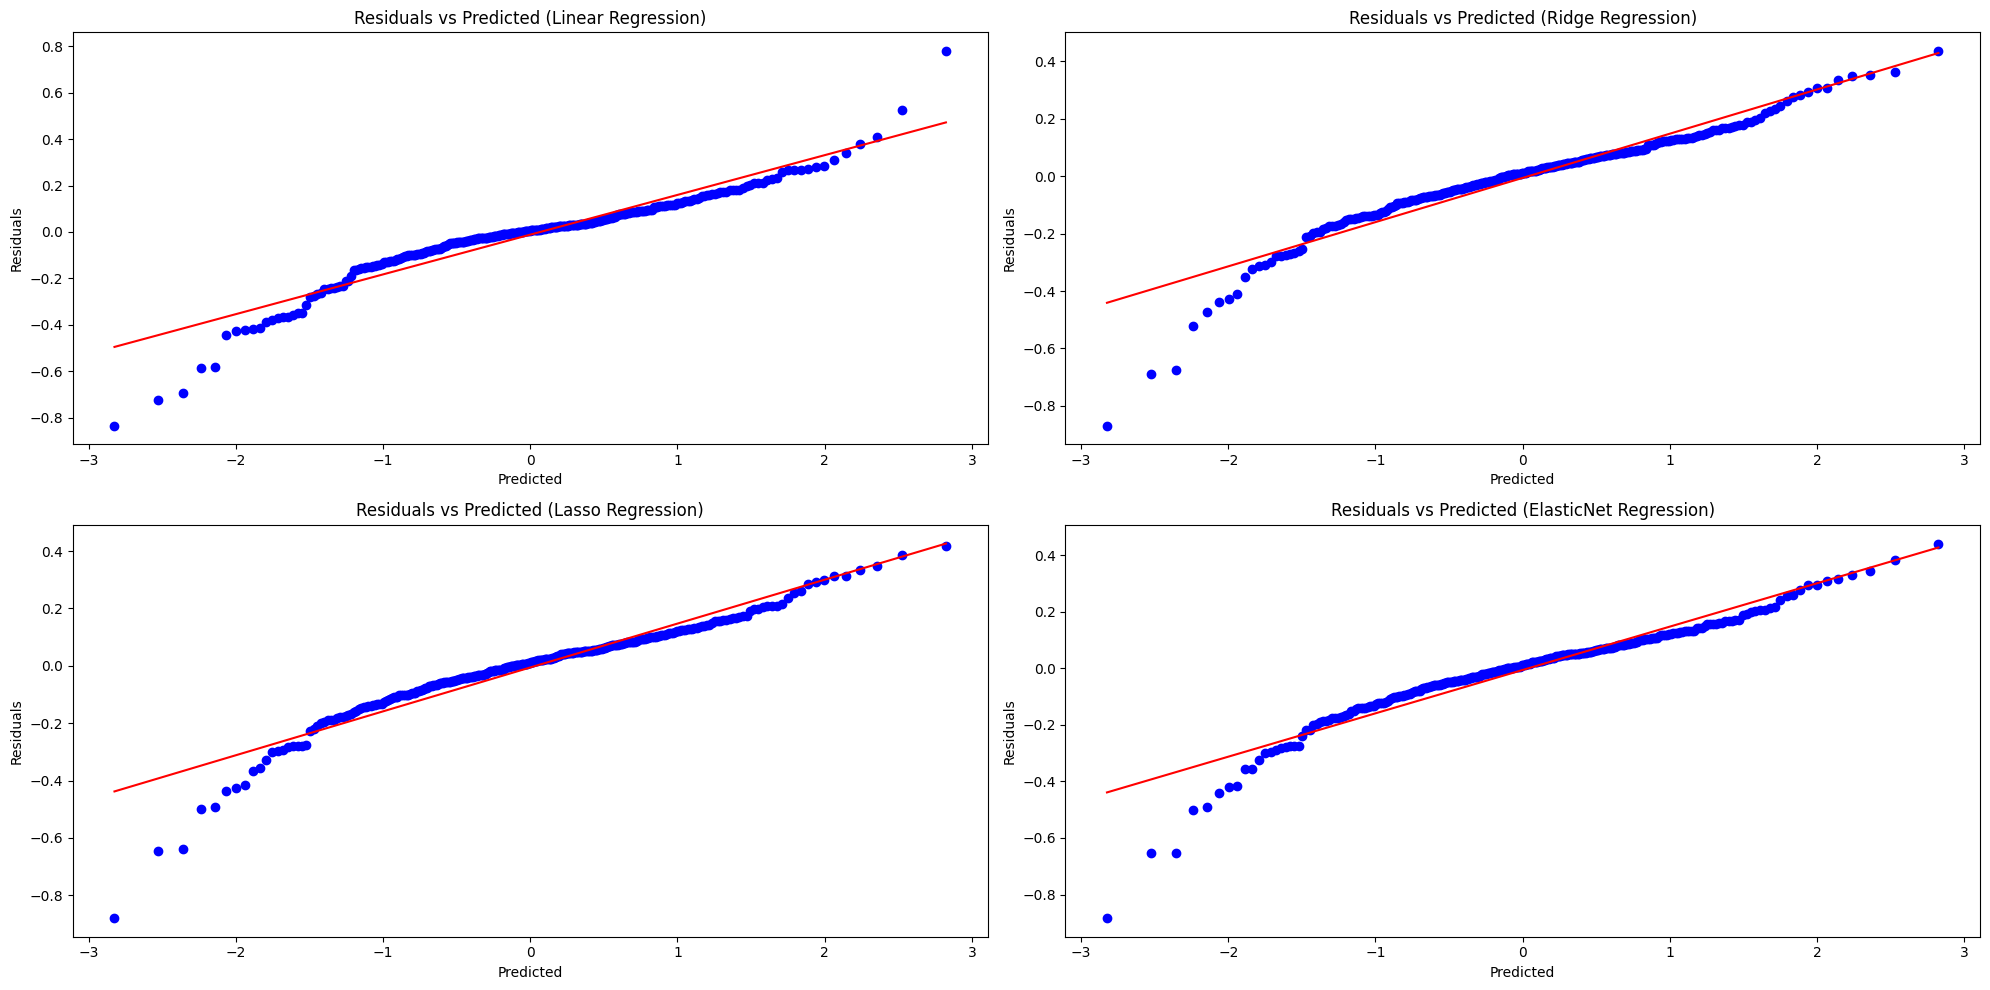

In [20]:
# QQ plot of residuals
plt.figure(figsize=(20, 10))

for i, (model_name, y_pred) in enumerate(predictions.items(), 1):
    residuals = y_val - y_pred
    
    plt.subplot(2, 2, i)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'Residuals vs Predicted ({model_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

Looking at the QQ plot of the residuals, the residuals seem to deviate from a normal distribution, especially at the tails. This may indicate that the model has limitations but deviations are common in real-world data.

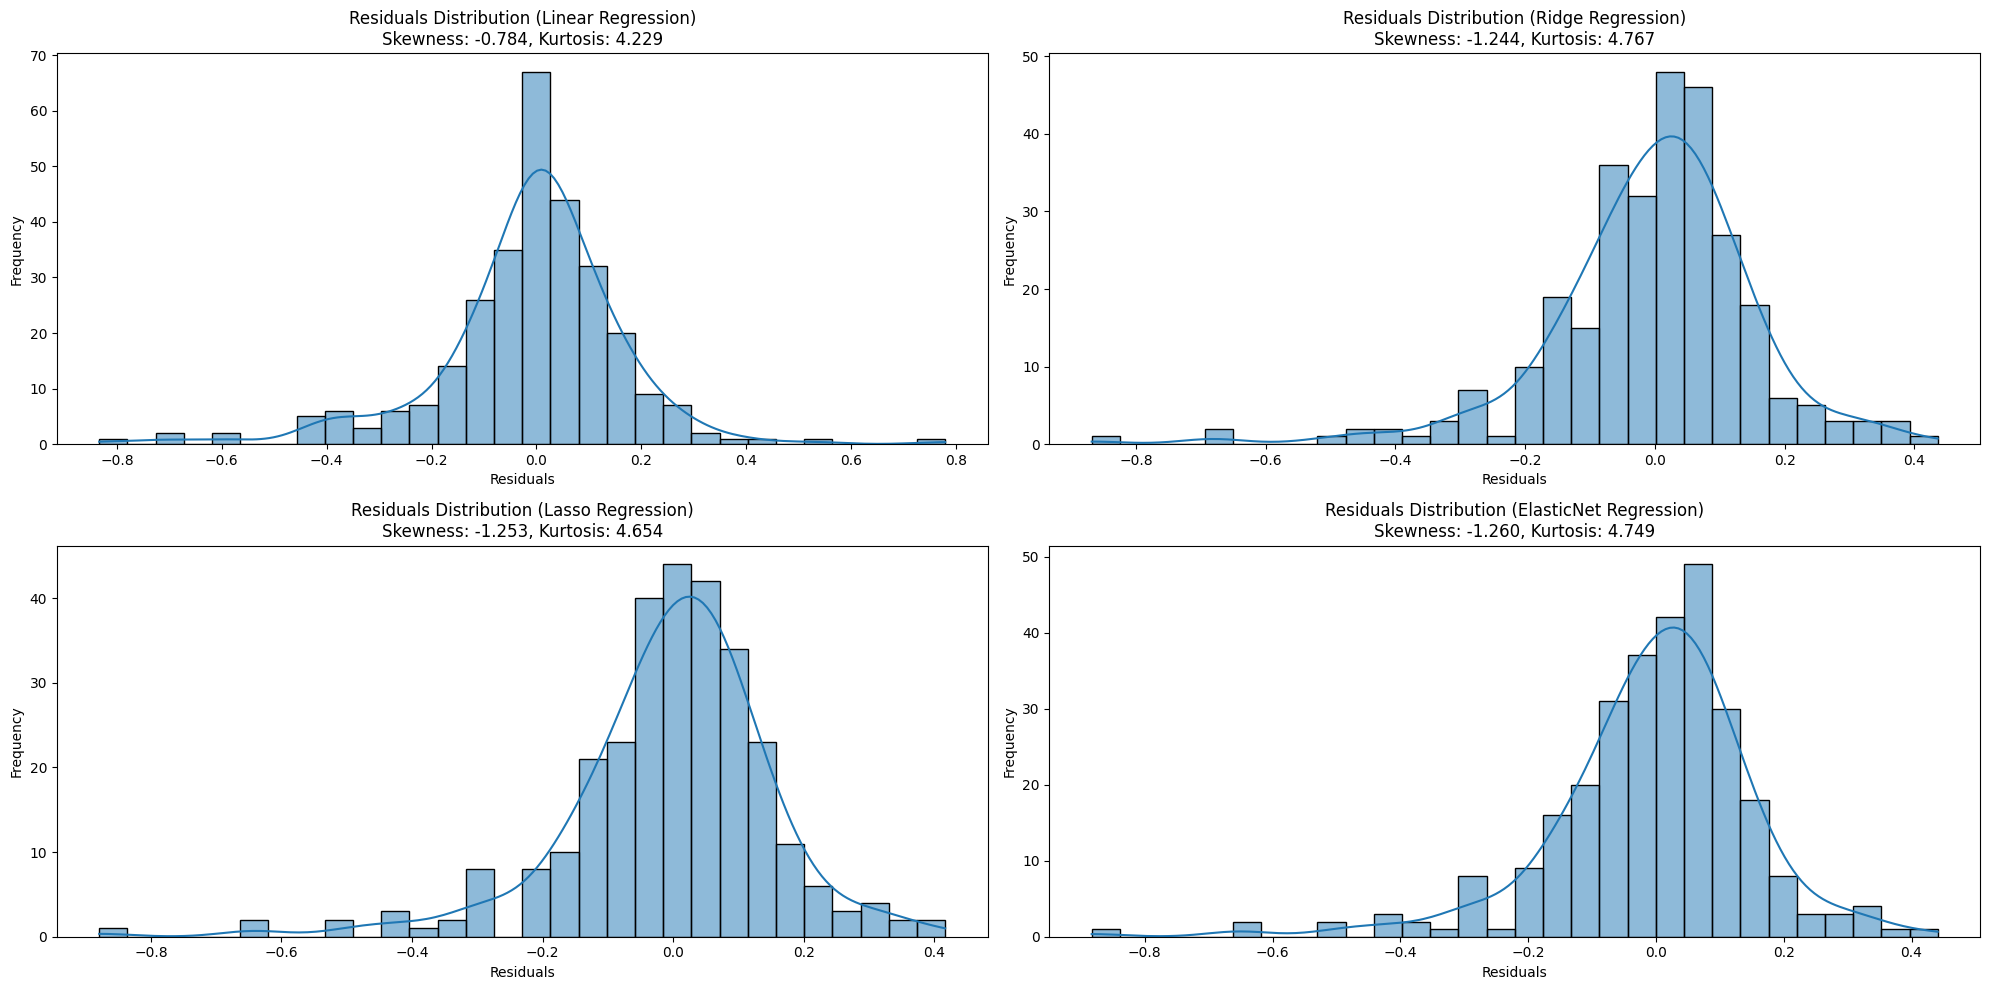

In [21]:
# Histogram plot of residuals with skewness and kurtosis
plt.figure(figsize=(20, 10))

for i, (model_name, y_pred) in enumerate(predictions.items(), 1):
    residuals = y_val - y_pred
    
    # Calculate skewness and kurtosis
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    
    plt.subplot(2, 2, i)
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(f'Residuals Distribution ({model_name})\nSkewness: {skewness:.3f}, Kurtosis: {kurtosis:.3f}')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Residuals Analysis Summary:
- Residuals range from: $209.85 to $266,815.11
- Quartiles:
    25% of predictions within: $6,299.97
    50% of predictions within: $12,752.50
    75% of predictions within: $24,647.23

20 residuals (6.85%) exceed 2 standard deviations.



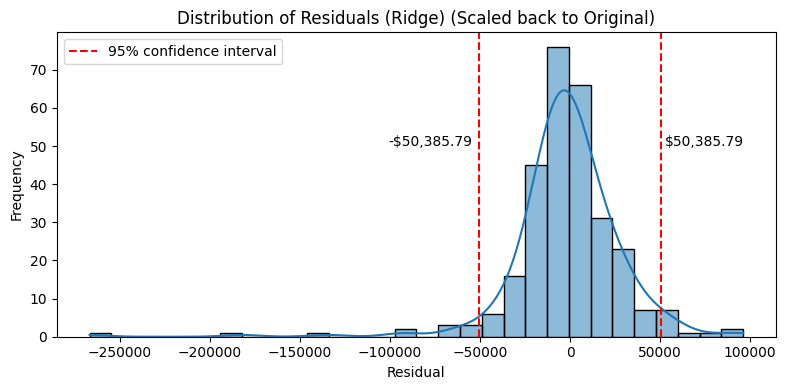

In [22]:
# Converting residuals back to original scale
y_true_orig = np.expm1(y_val)
y_pred_orig = np.expm1(y_pred_ridge)
residuals_orig = y_pred_orig - y_true_orig

# Standard deviation and average of errors
desc = abs(residuals_orig).describe()

summary = (
    f"Residuals Analysis Summary:\n"
    f"- Residuals range from: ${desc['min']:,.2f} to ${desc['max']:,.2f}\n"
    f"- Quartiles:\n"
    f"    25% of predictions within: ${abs(desc['25%']):,.2f}\n"
    f"    50% of predictions within: ${abs(desc['50%']):,.2f}\n"
    f"    75% of predictions within: ${abs(desc['75%']):,.2f}\n"
)
print(summary)

outlier_count = (abs(residuals_orig) > 2 * abs(desc['std'])).sum()
outlier_pct = 100 * outlier_count / desc['count']
print(f"{outlier_count} residuals ({outlier_pct:.2f}%) exceed 2 standard deviations.\n")

# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals_orig, bins=30, kde=True)
plt.title("Distribution of Residuals (Ridge) (Scaled back to Original)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(2 * desc['std'], color='red', linestyle='--', label = "95% confidence interval")
plt.text(x=2.1 * desc['std'], y = 50, s = f"${2 * desc['std']:,.2f}")
plt.text(x=-4 * desc['std'], y = 50, s = f"-${2 * desc['std']:,.2f}")
plt.axvline(-2 * desc['std'], color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Residuals Analysis Summary:
- Residuals range from: $45.64 to $257,223.44
- Quartiles:
    25% of predictions within: $5,962.46
    50% of predictions within: $12,818.13
    75% of predictions within: $23,996.81

20 residuals (6.85%) exceed 2 standard deviations.



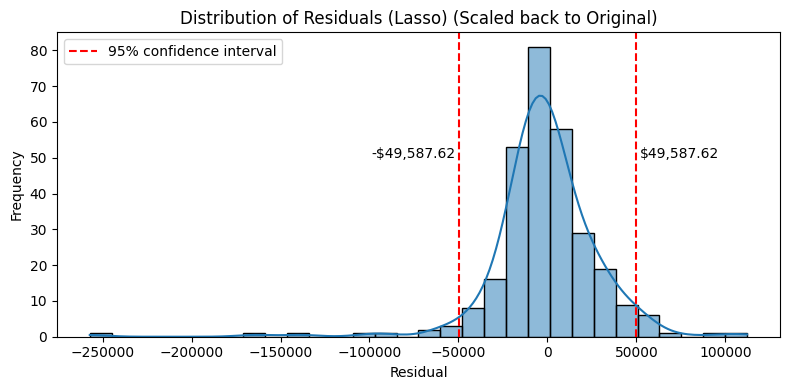

In [23]:
# Converting residuals back to original scale
y_pred_orig_lasso = np.expm1(y_pred_lasso)
residuals_orig_lasso = y_pred_orig_lasso - y_true_orig

# Standard deviation and average of errors
desc = abs(residuals_orig_lasso).describe()

summary = (
    f"Residuals Analysis Summary:\n"
    f"- Residuals range from: ${desc['min']:,.2f} to ${desc['max']:,.2f}\n"
    f"- Quartiles:\n"
    f"    25% of predictions within: ${abs(desc['25%']):,.2f}\n"
    f"    50% of predictions within: ${abs(desc['50%']):,.2f}\n"
    f"    75% of predictions within: ${abs(desc['75%']):,.2f}\n"
)
print(summary)

outlier_count = (abs(residuals_orig_lasso) > 2 * abs(desc['std'])).sum()
outlier_pct = 100 * outlier_count / desc['count']
print(f"{outlier_count} residuals ({outlier_pct:.2f}%) exceed 2 standard deviations.\n")

# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals_orig_lasso, bins=30, kde=True)
plt.title("Distribution of Residuals (Lasso) (Scaled back to Original)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(2 * desc['std'], color='red', linestyle='--', label = "95% confidence interval")
plt.text(x=2.1 * desc['std'], y = 50, s = f"${2 * desc['std']:,.2f}")
plt.text(x=-4 * desc['std'], y = 50, s = f"-${2 * desc['std']:,.2f}")
plt.axvline(-2 * desc['std'], color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Residuals Analysis Summary:
- Residuals range from: $9.05 to $269,208.91
- Quartiles:
    25% of predictions within: $6,254.13
    50% of predictions within: $12,856.55
    75% of predictions within: $23,615.51

20 residuals (6.85%) exceed 2 standard deviations.



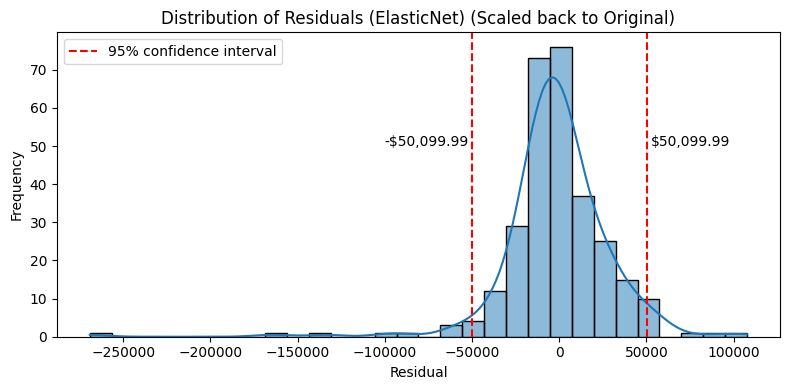

In [24]:
# Converting residuals back to original scale
y_pred_orig_elastic = np.expm1(y_pred_elastic)
residuals_orig_elastic = y_pred_orig_elastic - y_true_orig

# Standard deviation and average of errors
desc = abs(residuals_orig_elastic).describe()

summary = (
    f"Residuals Analysis Summary:\n"
    f"- Residuals range from: ${desc['min']:,.2f} to ${desc['max']:,.2f}\n"
    f"- Quartiles:\n"
    f"    25% of predictions within: ${abs(desc['25%']):,.2f}\n"
    f"    50% of predictions within: ${abs(desc['50%']):,.2f}\n"
    f"    75% of predictions within: ${abs(desc['75%']):,.2f}\n"
)
print(summary)

outlier_count = (abs(residuals_orig_elastic) > 2 * abs(desc['std'])).sum()
outlier_pct = 100 * outlier_count / desc['count']
print(f"{outlier_count} residuals ({outlier_pct:.2f}%) exceed 2 standard deviations.\n")

# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals_orig_elastic, bins=30, kde=True)
plt.title("Distribution of Residuals (ElasticNet) (Scaled back to Original)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(2 * desc['std'], color='red', linestyle='--', label = "95% confidence interval")
plt.text(x=2.1 * desc['std'], y = 50, s = f"${2 * desc['std']:,.2f}")
plt.text(x=-4 * desc['std'], y = 50, s = f"-${2 * desc['std']:,.2f}")
plt.axvline(-2 * desc['std'], color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

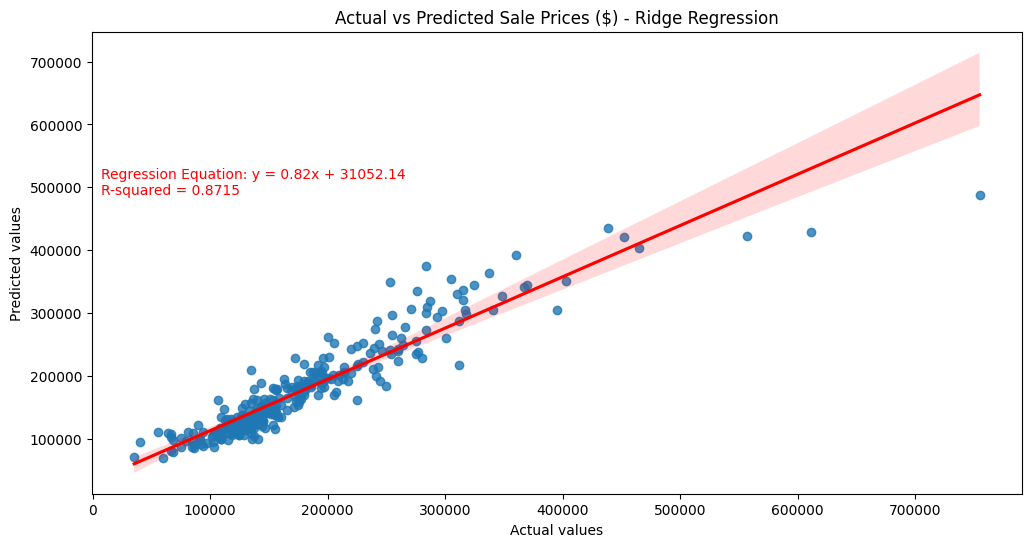

In [25]:
# Calculate regression coefficients
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_orig, y_pred_orig)
r_squared = r_value**2

# Format equation string
equation = f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_squared:.4f}'

# Scatterplot of actual vs predicted
plt.figure(figsize=(12, 6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={"color": "red"})
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted Sale Prices ($) - Ridge Regression')

# Add equation text on plot (adjust coordinates as needed)
plt.text(min(y_true_orig) * 0.2, max(y_pred_orig) * 1, s = f"Regression Equation: {equation}", color='red')

plt.show()

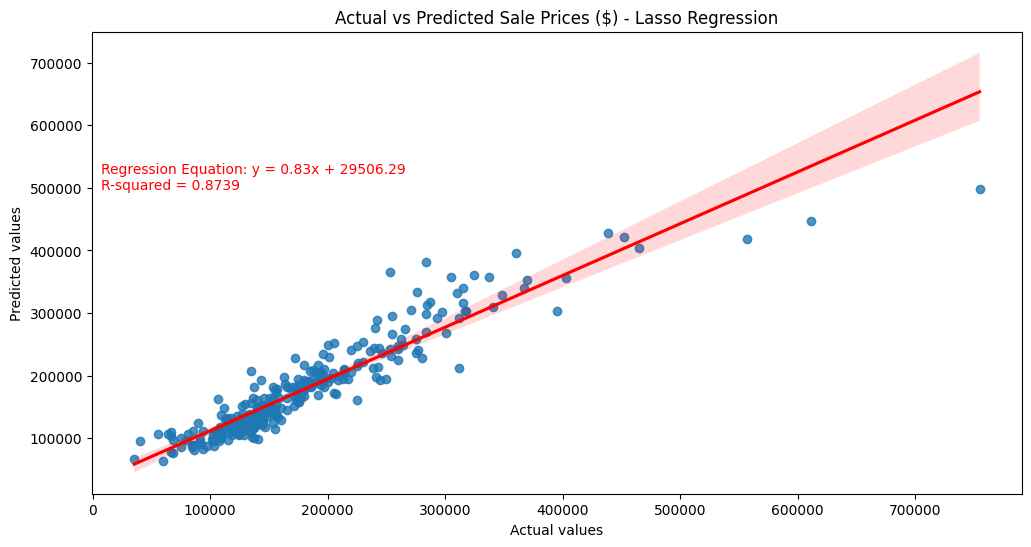

In [26]:
# Calculate regression coefficients
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_orig, y_pred_orig_lasso)
r_squared = r_value**2

# Format equation string
equation = f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_squared:.4f}'

# Scatterplot of actual vs predicted
plt.figure(figsize=(12, 6))
sns.regplot(x=y_true_orig, y=y_pred_orig_lasso, line_kws={"color": "red"})
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted Sale Prices ($) - Lasso Regression')

# Add equation text on plot (adjust coordinates as needed)
plt.text(min(y_true_orig) * 0.2, max(y_pred_orig_lasso) * 1, s = f"Regression Equation: {equation}", color='red')

plt.show()

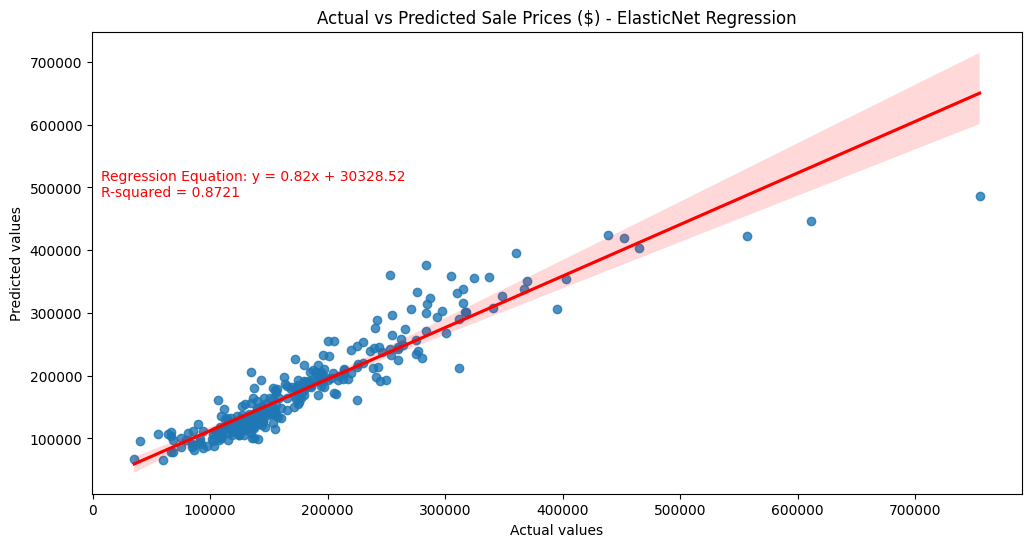

In [27]:
# Calculate regression coefficients
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_orig, y_pred_orig_elastic)
r_squared = r_value**2

# Format equation string
equation = f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_squared:.4f}'

# Scatterplot of actual vs predicted
plt.figure(figsize=(12, 6))
sns.regplot(x=y_true_orig, y=y_pred_orig_elastic, line_kws={"color": "red"})
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted Sale Prices ($) - ElasticNet Regression')

# Add equation text on plot (adjust coordinates as needed)
plt.text(min(y_true_orig) * 0.2, max(y_pred_orig_elastic) * 1, s = f"Regression Equation: {equation}", color='red')

plt.show()

**Analysis of Residuals and Predictions**

After analyzing the residuals, we observed the following:
1. Precision: On average, predictions are off by <1%, and 95% of errors within the $50,000 range.
2. Outliers: The model performs well for almost all homes, with errors beyond the 95% confidence interval in about 7% of the households.
3. Skew: The residuals distribution is heavily skewed to the left, indicating that the model tends to understate home values.

The model is solid and dependable overall, particularly for most mid- to lower-priced homes.

### 7. CROSS-VALIDATION

From code above: <br>
Best alpha for Ridge: 100 <br>
Best alpha for Lasso: 0.001 <br>
Best alpha for ElasticNet: 0.01 <br>
Best l1_ratio for ElasticNet: 0.1

To assess if the models' performance is due to a "fluke", we will use cross-validation on the training set with the selected features, including the polynomial features. We will also scale the features in our evaluation.

In [28]:
# Feature matrix and target
X_full = X_train_all[selected_features]
y_full = train_set['SalePrice_normalized']

# Define pipelines
pipelines = {
    'Linear Regression': make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), LinearRegression()),
    'Ridge Regression': make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), Ridge(alpha=100)),
    'Lasso Regression': make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), Lasso(alpha=0.001)),
    'ElasticNet Regression': make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=0.1)),
}

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Collect results
results = []

for name, model in pipelines.items():
    y_pred = cross_val_predict(model, X_full, y_full, cv=kf)
    
    r2 = r2_score(y_full, y_pred)
    mape = mean_absolute_percentage_error(y_full, y_pred) * 100  # in percentage
    mse = mean_squared_error(y_full, y_pred)
    rmse = np.sqrt(mse)
    
    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
    })

# Create and print the results DataFrame
metrics_df = pd.DataFrame(results)
print(metrics_df)

                   Model      R²  MAPE (%)     MSE    RMSE
0      Linear Regression  0.7802      1.01  0.0335  0.1830
1       Ridge Regression  0.8651      0.85  0.0206  0.1434
2       Lasso Regression  0.8636      0.85  0.0208  0.1442
3  ElasticNet Regression  0.8651      0.85  0.0206  0.1434


**Cross-Validation Design** <br>
We used a five-fold cross-validation design to split the training data into five parts, train on four parts, and validate themselves on the fifth — including rotating the models through each part. By evaluating the model's performance across different samples and protects against overfitting. These results show that the Ridge Regression model generalizes much better to unseen data compared to the standard Linear Regression and even the other models, likely due to its regularization and ability to handle multicollinearity among the polynomial features.

**Interpretation of Key Results**

We evaluated model performance using four different measures: R-squared error (R²), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).  Across the board, we noted that Linear Regression performed worse than the other models in both cross-validation and train-test split validation sets as it got an R² score of 0.7802, while the regularized models had substantially better performance, which shows us that regularization is crucial when predicting house prices. 

Ridge's slight edge suggests that the model benefits from keeping all the features but also from reducing their impact. Overall, the regularized approaches demonstrate superior ability to capture the underlying patterns in house price data while avoiding overfitting.

### 8. MODEL EVALUATION

In [29]:
# Converting boolean columns to numeric 0 & 1 values
X_full = X_full.apply(pd.to_numeric, errors='coerce')
bool_cols = X_full.select_dtypes(include='bool').columns
X_full[bool_cols] = X_full[bool_cols].astype(int)

In [30]:
# Evaluating variance inflation factor (VIF) to evaluate features for multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = X_full.columns
vif_data["VIF"] = [variance_inflation_factor(X_full.values, i) for i in range(len(X_full.columns))]
print("VIF Analysis:")
display(vif_data.assign(VIF=vif_data["VIF"].round(4)).sort_values('VIF', ascending=False))

# Add Durbin-Watson test for independence
dw_stat_ridge = durbin_watson(y_pred_ridge - y_val)
dw_stat_lasso = durbin_watson(y_pred_lasso - y_val)
dw_stat_elastic = durbin_watson(y_pred_elastic - y_val)
print(f"\nDurbin-Watson statistic (Ridge): {dw_stat_ridge:.4f}")
print(f"Durbin-Watson statistic (Lasso): {dw_stat_lasso:.4f}")
print(f"Durbin-Watson statistic (ElasticNet): {dw_stat_elastic:.4f}")

# Add constant to exog for Breusch-Pagan test
exog_with_const = sm.add_constant(X_val_scaled)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(y_pred_ridge - y_val, exog_with_const)
print(f"\nBreusch-Pagan test p-value (Ridge): {bp_pvalue:.4f}")

VIF Analysis:


,Feature,VIF
6,GarageYrBlt,18885.1295
1,YearBuilt,14793.7052
2,YearRemodAdd,13363.9736
10,TotalSF,337.9716
0,OverallQual,66.6012
13,TotalSF_over_2000,46.7273
4,TotRmsAbvGrd,40.4201
7,GarageCars,37.9874
3,1stFlrSF,36.0398
8,GarageArea,32.2515



Durbin-Watson statistic (Ridge): 2.0430
Durbin-Watson statistic (Lasso): 2.0435
Durbin-Watson statistic (ElasticNet): 2.0514

Breusch-Pagan test p-value (Ridge): 0.1142


There are some features with very high collinearity. However, using Ridge and other regularization regression models solves this for us by penalizing large coefficients.

In [31]:
# Calculating coefficient shrinkage caused by Ridge Regression
max_lr_coef = round(np.max(np.abs(lr.coef_)), 4)
max_ridge_coef = round(np.max(np.abs(ridge.coef_)), 4)
max_lasso_coef = round(np.max(np.abs(lasso.coef_)), 4)
max_elastic_coef = round(np.max(np.abs(best_elastic.coef_)), 4)

print(f"Ridge shrinkage effect (alpha={10}):")
print(f"Linear regression max coefficient: {max_lr_coef}")
print(f"\nRidge regression max coefficient: {max_ridge_coef}")
print(f"Lasso regression max coefficient: {max_lasso_coef}")
print(f"ElasticNet regression max coefficient: {max_elastic_coef}")

print(f"\nShrinkage ratio: {round((max_lr_coef - max_ridge_coef) * 100 / max_lr_coef, 2)}%")

Ridge shrinkage effect (alpha=10):
Linear regression max coefficient: 8.726

Ridge regression max coefficient: 0.0391
Lasso regression max coefficient: 0.2123
ElasticNet regression max coefficient: 0.08

Shrinkage ratio: 99.55%


As seen above, the Ridge model performs best on a cross-validated train-test split. We will resample the training and validation sets through a method called bootstrapping and stress-test our model.

In [32]:
# Bootstrap CI
boot_preds = []

for i in range(1000):
    X_boot, y_boot = resample(X_train_scaled, y_train)
    ridge.fit(X_boot, y_boot)
    boot_preds.append(ridge.predict(X_val_scaled))

# 95% CI
lower = np.percentile(boot_preds, 2.5, axis=0)
upper = np.percentile(boot_preds, 97.5, axis=0)

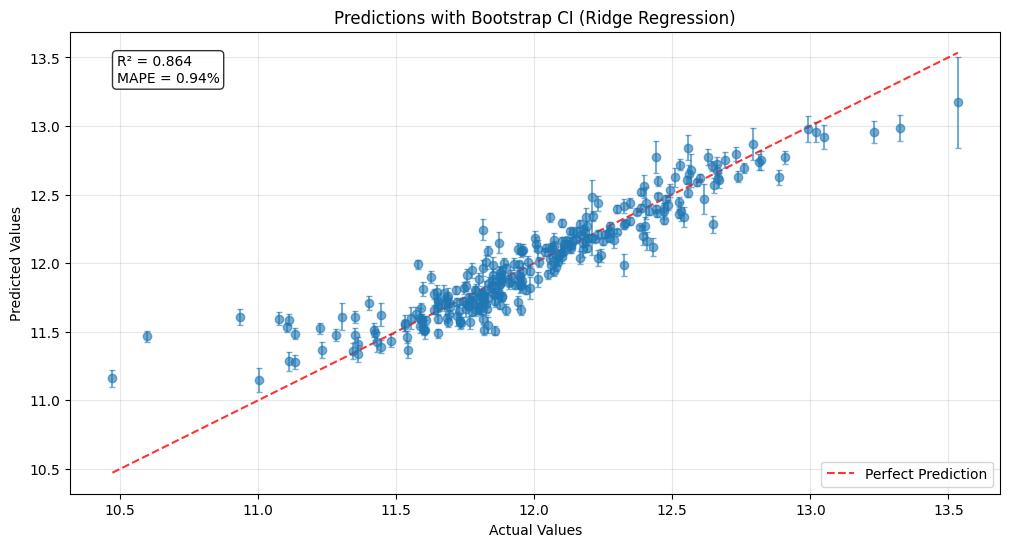

In [33]:
mean_preds = np.mean(boot_preds, axis=0)
errors = upper - lower  # Error bar size

# Add some useful statistics
plt.figure(figsize=(12, 6))
plt.errorbar(y_val, mean_preds, yerr=errors/2, fmt='o', alpha=0.6, capsize=2)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', alpha=0.8, label='Perfect Prediction')

# Add R² and RMSE
r2 = r2_score(y_val, mean_preds)
mape = (mean_absolute_percentage_error(y_val, mean_preds))
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMAPE = {100*mape:.2f}%', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predictions with Bootstrap CI (Ridge Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. This chart shows each prediction as a dot and the error bars show the possible range of those predictions based on 100 resamples and the red line represents actuals.

2. We also measure the R² score to check if the model explains the house prices well and also the MAPE that shows the average error on an absolute basis.

#### 8.1 MODEL ASSUMPTIONS

When building our regression models, we assumed the following:

1. *Linearity*: We assume that the features in the data have linear relationships with the target, `SalePrice`. We confirmed this by performing a correlation analysis to the target variable. Where we could not detect linear relationships, we (a) created polynomial terms (e.g., GrLivArea², GarageCars * TotalSF) to transform these features for our evaluation & (b) added piecewise components like TotalSF_over_2000 to model diminishing returns for large homes.

2. *Independence of Errors*: We assume that modeling errors will be unrelated to each other. We confirmed this by plotting residuals for both models and confirmed that they showed no clear trends. Further, the Durbin-Watson statistic of 2.0322 shows that the data is very close to the ideal value of 2, indicating that the errors/residuals are unrelated.

3. *Normality of Errors*: We assume that the errors will be normally distributed. We visualized them in a QQ plot and confirmed that they mostly follow a straight line. Further, our previous normalization of `SalePrice` would have a knock-on effect on the model's residuals.

4. *Homoskedacity (Constant Error Variance)*: We assume that errors will be equally spread. We confirmed this residuals by visualizing the errors in a QQ plot and evaluating it for funneling or spreading patterns . Further, we evaluated the residuals using a Breusch-Pagan test that showed a p-value higher than 0.05, rejecting the null hypothesis of equal variance and supporting our assumption of homoskedasticity in our model.

5. *Multicollinearity*: We assume that the features will be related to each other as houses are generally built using set proportions between these features. Further, excluding features correlating with each other might remove important relationships. By using Ridge Regression, we penalize these relationships with large coefficients and shrink them to prevent overfitting.

6. *Feature Relevance*: Since we lack domain expertise, we assume that all the top features selected are relevant for real-estate modeling.

#### 8.2 FEATURE IMPORTANCE

We looked at the top features used in the better performing model, i.e. the Ridge model, used in predicting house prices. As we used polynomial features (i.e., features created by combining with multiple features), we get the actual feature names generated during polynomial transformation and then derive only the absolute values from the coefficients.

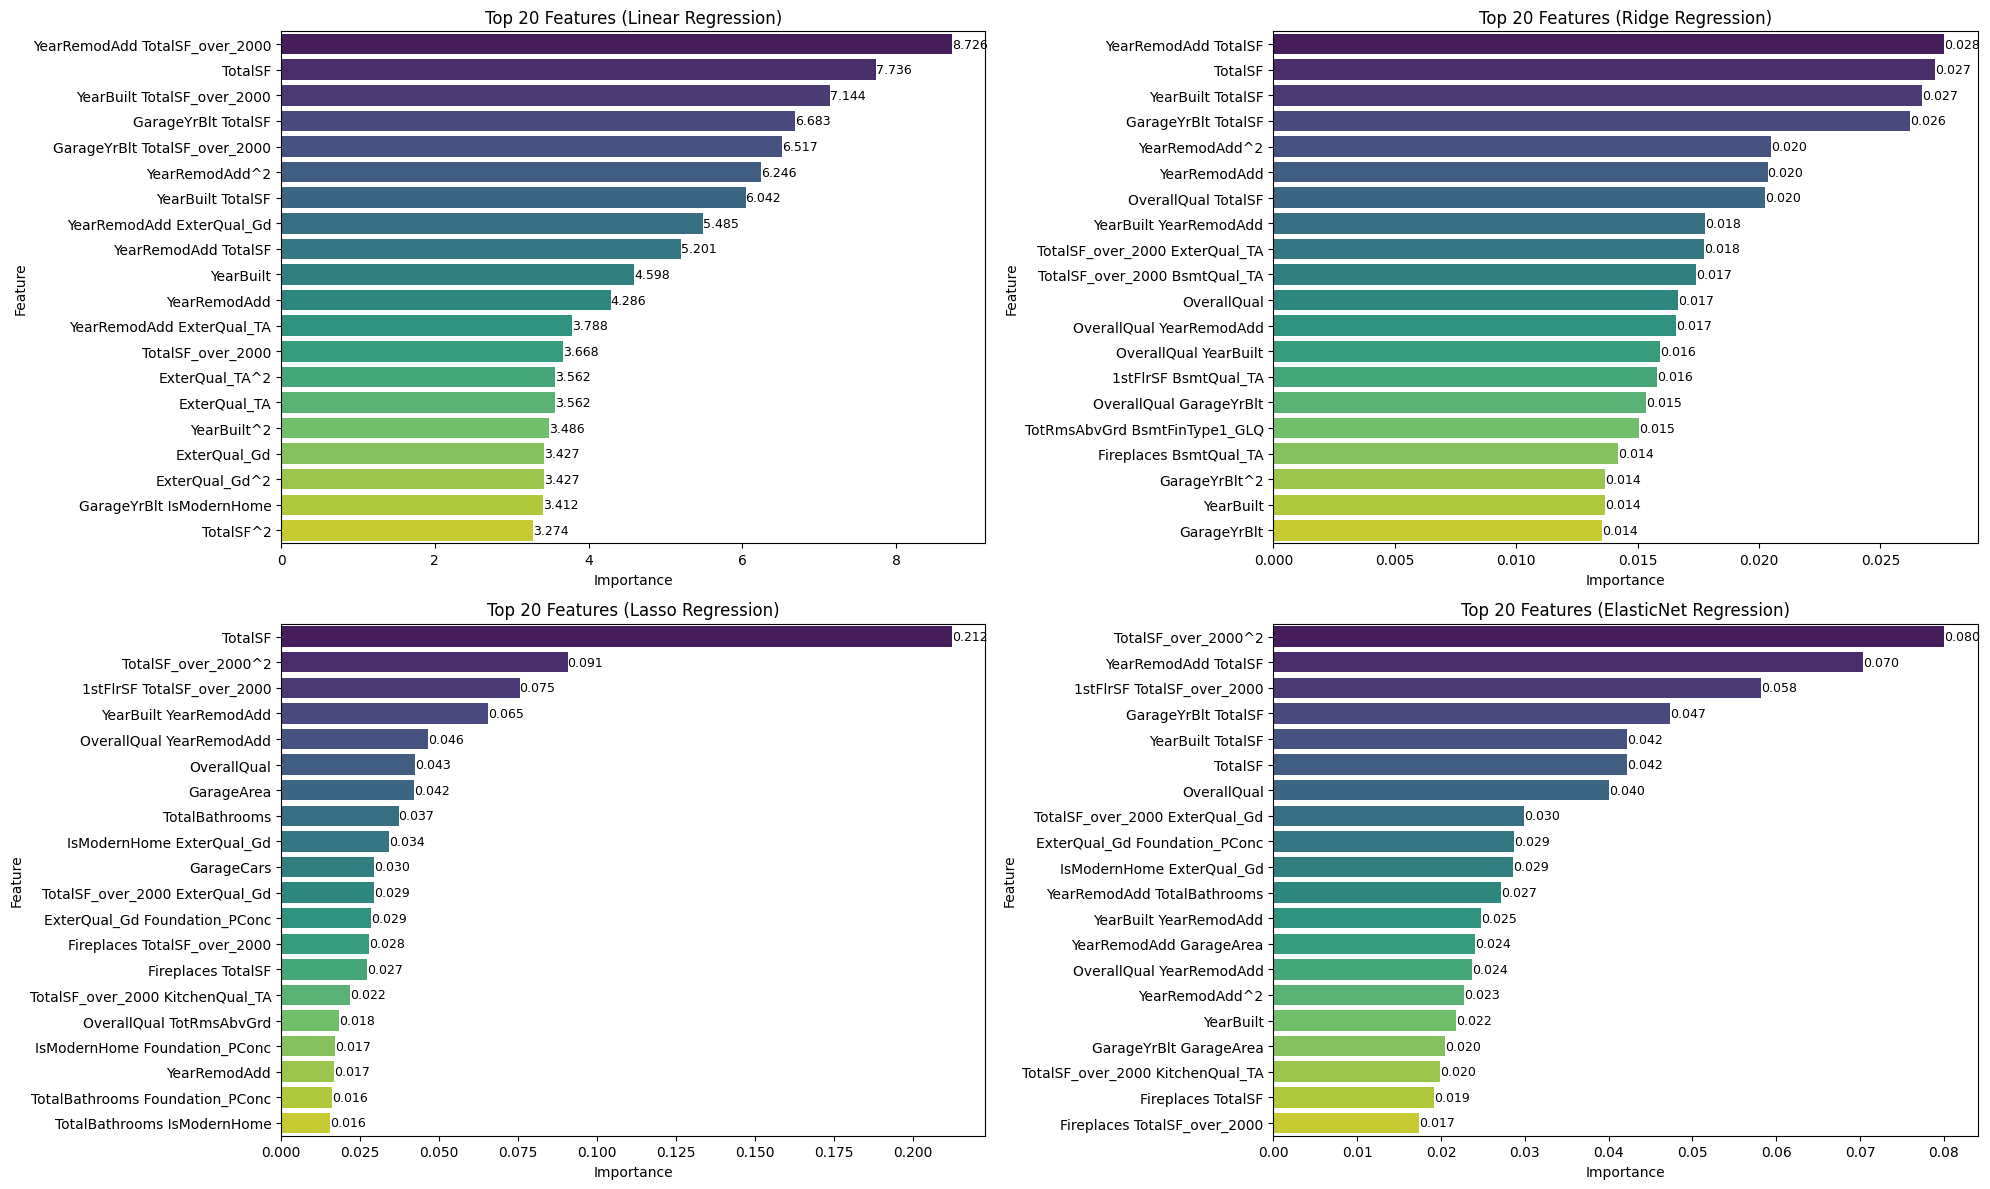

In [34]:
# Get feature names after polynomial transformation
poly_feature_names = poly.get_feature_names_out(selected_features)

# Define models and their names
models = {
    'Linear Regression': lr,
    'Ridge Regression': ridge,
    'Lasso Regression': lasso,
    'ElasticNet Regression': best_elastic
}

# Create importance DataFrames for all models
importance_dfs = {}
for name, model in models.items():
    importance = np.abs(model.coef_)
    df = pd.DataFrame({'Feature': poly_feature_names, 'Importance': importance})
    importance_dfs[name] = df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(20, 12))

for i, (model_name, df) in enumerate(importance_dfs.items(), 1):
    plt.subplot(2, 2, i)
    ax = sns.barplot(x='Importance', y='Feature', data=df.head(20), palette='viridis')
    plt.title(f'Top 20 Features ({model_name})')
    plt.tight_layout()
    
    # Add data labels
    for j, (importance, feature) in enumerate(zip(df.head(20)['Importance'], df.head(20)['Feature'])):
        ax.text(importance, j, f"{importance:.3f}", va='center', ha='left', fontsize=9, color='black')

plt.show()

Based on the four feature importance charts, we observed that each regression model evaluates the same set of features very differently.

1. Linear Regression seems to focus heavily on shows the most concentrated feature selection, with year-related features (YearRemodelAdd, YearBuilt) and total square footage dominating the importance rankings.

2. Ridge Regression seems more balanced as it has distributed importance across several features but still prioritizes total square footage and age-related variables. The range of the importance values is much smaller vs. linear regression, indicating that no one feature dominates in this model.

3. Lasso Regression shows limited importance in most features but total square footage is shown to be overwhelmingly important, whereas ElasticNet is balanced between Ridge and Lasso with a moderate feature importance spread. 

In our opinion, Ridge seems to be the most optimal choice as it includes a variety of features while also treating them as important on a more comprehensive basis.

### 9. FINAL PREDICTIONS

In [44]:
# Ridge Submission
test_full = pd.get_dummies(test, drop_first=True)
X_test = test_full[selected_features]
X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)
y_test_pred_normalized = ridge.predict(X_test_scaled)
y_test_pred = np.expm1(y_test_pred_normalized)

ridge_submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred
})

ridge_submission.to_csv("ridge_submission.csv", index=False)
print("Test predictions saved to ridge_submission.csv")

Test predictions saved to ridge_submission.csv


In [45]:
# Lasso submission
y_test_pred_normalized_lasso = lasso.predict(X_test_scaled)
y_test_pred_lasso = np.expm1(y_test_pred_normalized_lasso)

lasso_submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred_lasso
})

lasso_submission.to_csv("lasso_submission.csv", index=False)
print("Test predictions saved to lasso_submission.csv")

Test predictions saved to lasso_submission.csv


In [46]:
# ElasticNet submission
y_test_pred_normalized_elastic = best_elastic.predict(X_test_scaled)
y_test_pred_elastic = np.expm1(y_test_pred_normalized_elastic)

elastic_submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred_elastic
})

elastic_submission.to_csv("elastic_submission.csv", index=False)
print("Test predictions saved to elastic_submission.csv")

Test predictions saved to elastic_submission.csv


#### 9.1 DISCUSSION OF BEST PERFORMING MODEL IN LAYMAN'S TERMS

Our model looks at many features (inherent and engineered) to predict a house's sale price, such as the number of bathrooms, living space, garage size, and whether it has a fireplace.

In the chart above, we showed how much impact a specific feature had on the predicted price. 

**If you're trying to understand what drives house prices:**
1. Total Square Footage: Our analysis showed that total square footage influenced house prices the most. This is logical as bigger houses will usually be priced higher.

2. Age: Our analysis revealed that house age influences prices, especially when evaluated with square footage. Generally, we would expect newer houses to cost more and vice versa.

3. First Floor Size: Our analysis further revealed that first floor size is an important feature, which aligns with our understand that more main-level living space would be valuable, especially in larger houses.

4. External Quality Features: External quality factors, including foundation quality and general exterior quality, appear prominently in our top features (ranks 7th and 10th), confirming that well-built, high-quality homes fetch premium prices.

5. Quality: Exterior and overall quality also seem to be top predictors, especially when combined with house age, time since remodeling, and total square footage, showing that quality assessments are crucial pricing factors.

Because the Ridge model retains all features but weights them by importance, we can see the relative contribution of each factor. The clear dominance of total square footage variations in the top positions confirms that house size remains the primary driver of home values, while quality, age, and amenity factors provide important additional predictive power for our stakeholders to focus on.

<p style="page-break-after:always;"></p>

# Appendix 2: Kaggle Profile and Submissions

<i> Uploader's Kaggle profile: https://www.kaggle.com/shishirdeshpandenwu </i>

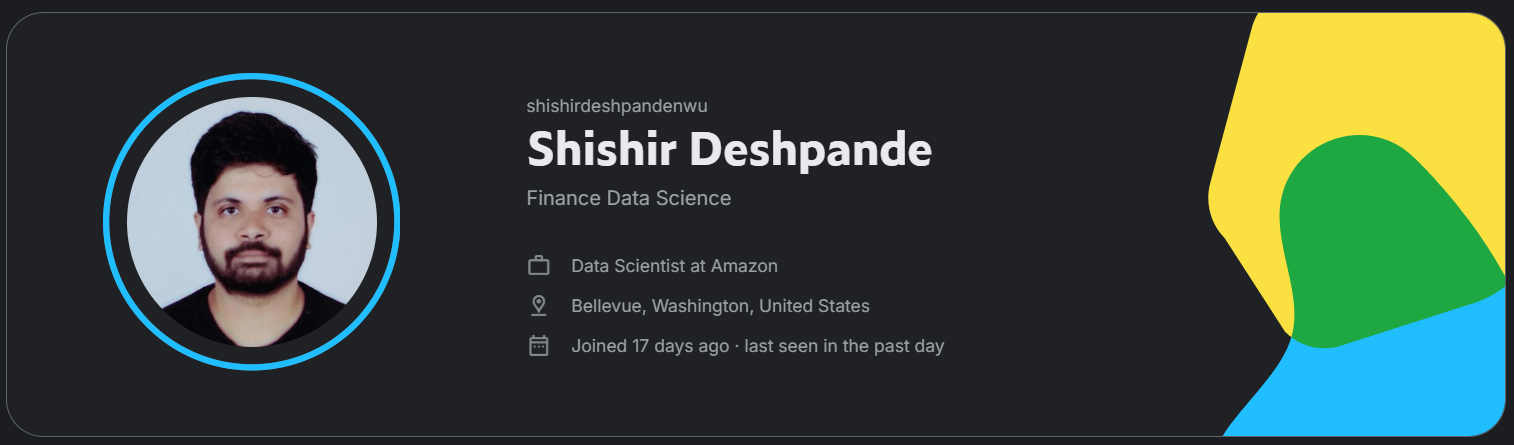

<i> Using cross-validated, hyperparameter-tuned Ridge, Lasso & ElasticNet Regression Models with engineered and polynomial features </i> <br>
<img src="Ridge, Lasso & ElasticNet.png" height = 550 >